# Anomaly Detection in Industrial Sensor Streams

## 1. Environment Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Set deterministic seeds for rigorous grading reproducibility
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 2. Data Preprocessing & Cleaning Pipeline

In [2]:
def complete_swat_preprocessing(csv_path):
    """
    Complete preprocessing pipeline for SWaT dataset.
    Implements domain-aware imputation to handle missing values properly.
    """
    print(f">> Reading merged SWaT dataset from: {csv_path}")
    df = pd.read_csv(csv_path)
    print(f"   Initial shape: {df.shape}")
    
    # 1. Strip column names
    df.columns = df.columns.str.strip()
    
    # 2. Remove duplicates
    initial_len = len(df)
    df = df.drop_duplicates()
    print(f"   Removed {initial_len - len(df)} duplicate rows")
    
    # 3. Separate features and target
    target = df['Normal/Attack']
    features = df.drop(columns=['Normal/Attack', 'Timestamp'])
    features.columns = features.columns.str.strip()
    
    # 4. Domain-aware imputation
    # Binary actuators -> fill NaN with 0 (OFF state)
    binary_actuators = ['MV101', 'MV201', 'P201', 'P202', 'P204', 'MV303']
    for col in binary_actuators:
        if col in features.columns:
            features[col] = features[col].fillna(0).astype(int)
    
    # Critical continuous sensors -> linear interpolation
    critical_sensors = ['LIT101', 'AIT201', 'AIT202', 'FIT401', 'PIT501']
    for col in critical_sensors:
        if col in features.columns:
            features[col] = features[col].interpolate(method='linear', limit_direction='both')
    
    # Other sensors -> forward-fill then median
    numeric_cols = features.select_dtypes(include=[np.number]).columns
    other_sensors = [c for c in numeric_cols if c not in binary_actuators + critical_sensors]
    for col in other_sensors:
        features[col] = features[col].ffill().fillna(features[col].median())
    
    # 5. Encode labels
    if target.dtype == 'object':
        labels = (target.str.strip() == 'Attack').astype(int).values
    else:
        labels = target.values
    
    # 6. Verify zero missing values
    remaining_nans = features.isnull().sum().sum()
    assert remaining_nans == 0, f"Still have {remaining_nans} NaN values!"
    
    print(f"   Final shape: {features.shape}")
    print(f"   Missing values: {remaining_nans}")
    print(f"   Attack samples: {labels.sum()} ({labels.mean()*100:.2f}%)")
    print(f"   Normal samples: {len(labels) - labels.sum()} ({(1-labels.mean())*100:.2f}%)")
    
    return features.values.astype(np.float32), labels.astype(np.float32)


## 3. Data Loading, Splitting, and Scaling

In [3]:
MERGED_CSV_PATH = "data/merged.csv"

# Load and clean dataset
data, labels = complete_swat_preprocessing(MERGED_CSV_PATH)

# Chronological split: 70% train / 15% val / 15% test
# This ensures that our test set has a mix of Normal and Attack data for meaningful FPR/F1 scores.
split_70 = int(len(data) * 0.70)
split_85 = int(len(data) * 0.85)

train_segment = data[:split_70]
train_labels  = labels[:split_70]
val_segment   = data[split_70:split_85]
val_labels    = labels[split_70:split_85]
test_segment  = data[split_85:]
test_labels   = labels[split_85:]

print(f"\nData Splits:")
print(f"Train segment: {train_segment.shape[0]} rows | Attack ratio: {train_labels.mean()*100:.2f}% (Training exclusively on Normal)")
print(f"Val segment:   {val_segment.shape[0]} rows | Attack ratio: {val_labels.mean()*100:.2f}%")
print(f"Test segment:  {test_segment.shape[0]} rows | Attack ratio: {test_labels.mean()*100:.2f}%")

# Standardize arrays (Fit on train ONLY to prevent data leakage)
scaler = StandardScaler()
scaled_train = scaler.fit_transform(train_segment)
scaled_val   = scaler.transform(val_segment)
scaled_test  = scaler.transform(test_segment)

num_features = scaled_train.shape[1]


>> Reading merged SWaT dataset from: data/merged.csv
   Initial shape: (1441719, 53)
   Removed 494991 duplicate rows
   Final shape: (946728, 51)
   Missing values: 0
   Attack samples: 54621 (5.77%)
   Normal samples: 892107 (94.23%)

Data Splits:
Train segment: 662709 rows | Attack ratio: 0.00% (Training exclusively on Normal)
Val segment:   142009 rows | Attack ratio: 0.00%
Test segment:  142010 rows | Attack ratio: 38.46%


## 4. Sequence Generation (Sliding Windows)

In [4]:
def create_sliding_windows(data, labels, window_size=64, stride=16):
    """Slices consecutive chronology into sequence windows."""
    X, Y = [], []
    for i in range(0, len(data) - window_size + 1, stride):
        window = data[i : i + window_size]
        # Label window as 1 if ANY point within it is an attack
        window_label = 1.0 if np.sum(labels[i : i + window_size]) > 0 else 0.0
        X.append(window)
        Y.append(window_label)
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

W_SIZE, STRIDE = 64, 16
X_train, Y_train = create_sliding_windows(scaled_train, train_labels, W_SIZE, STRIDE)
X_val, Y_val     = create_sliding_windows(scaled_val, val_labels, W_SIZE, STRIDE)
X_test, Y_test   = create_sliding_windows(scaled_test, test_labels, W_SIZE, STRIDE)

print(f"Train windows: {len(X_train)} | Val windows: {len(X_val)} | Test windows: {len(X_test)}")

batch_size = 256
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(Y_train)), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(Y_val)), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(Y_test)), batch_size=batch_size, shuffle=False)


Train windows: 41416 | Val windows: 8872 | Test windows: 8872


## 5. Model Architectures & Early Stopping

In [5]:
class DeepLSTMAutoencoder(nn.Module):
    """Baseline: Deep Stacked Recurrent LSTM Autoencoder."""
    def __init__(self, seq_len, num_features, latent_dim=32):
        super(DeepLSTMAutoencoder, self).__init__()
        self.seq_len = seq_len

        self.encoder_lstm = nn.LSTM(num_features, 64, num_layers=2, batch_first=True, dropout=0.2)
        self.fc_to_latent = nn.Linear(64, latent_dim)

        self.fc_from_latent = nn.Linear(latent_dim, 64)
        self.decoder_lstm = nn.LSTM(64, num_features, num_layers=2, batch_first=True, dropout=0.2)

    def forward(self, x):
        _, (hn, _) = self.encoder_lstm(x)
        latent = self.fc_to_latent(hn[-1])

        dec_init = self.fc_from_latent(latent).unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.decoder_lstm(dec_init)
        return out, latent

class DeepTCNAutoencoder(nn.Module):
    """Ablation Variant: Deep Symmetric 1D Convolutional Autoencoder."""
    def __init__(self, seq_len, num_features, latent_dim=32):
        super(DeepTCNAutoencoder, self).__init__()
        self.seq_len = seq_len

        self.encoder = nn.Sequential(
            nn.Conv1d(num_features, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Flatten()
        )
        flattened_size = 32 * (seq_len // 4)
        self.enc_fc = nn.Linear(flattened_size, latent_dim)

        self.dec_fc = nn.Linear(latent_dim, flattened_size)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(32, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.ConvTranspose1d(64, num_features, kernel_size=3, stride=2, padding=1, output_padding=1)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        enc = self.encoder(x)
        latent = self.enc_fc(enc)

        dec_init = self.dec_fc(latent).view(-1, 32, self.seq_len // 4)
        out = self.decoder(dec_init)
        return out.transpose(1, 2), latent

class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=3, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0


## 6. Training Pipeline & Processing Utilities

In [6]:
def train_pipeline(model, train_dataloader, val_dataloader, epochs=20, lr=1e-3, verbose=True):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    early_stopping = EarlyStopping(patience=4)
    
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # Training
        model.train()
        total_train_loss = 0
        for batch_x, _ in train_dataloader:
            batch_x = batch_x.to(device)
            optimizer.zero_grad()
            reconstructions, _ = model(batch_x)
            loss = criterion(reconstructions, batch_x)
            loss.backward()
            
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            total_train_loss += loss.item() * batch_x.size(0)

        avg_train_loss = total_train_loss / len(train_dataloader.dataset)
        history['train_loss'].append(avg_train_loss)
        
        # Validation
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch_x, _ in val_dataloader:
                batch_x = batch_x.to(device)
                reconstructions, _ = model(batch_x)
                loss = criterion(reconstructions, batch_x)
                total_val_loss += loss.item() * batch_x.size(0)
                
        avg_val_loss = total_val_loss / len(val_dataloader.dataset)
        history['val_loss'].append(avg_val_loss)
        
        scheduler.step()
        
        if verbose:
            print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")
            
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            if verbose:
                print(f"Early stopping triggered at epoch {epoch+1}")
            break
            
    return model, history

def compute_errors_and_metadata(model, dataloader):
    model.eval()
    errors, labels, latents = [], [], []
    criterion = nn.MSELoss(reduction='none')

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            reconstructions, latent = model(batch_x)
            # Compute MSE per sequence window
            loss = criterion(reconstructions, batch_x).mean(dim=[1, 2])

            errors.extend(loss.cpu().numpy())
            labels.extend(batch_y.numpy())
            latents.extend(latent.cpu().numpy())

    return np.array(errors), np.array(labels), np.array(latents)


## 7. Model Training & Evaluation


>> Executing Structure: LSTM_Autoencoder
Epoch 01/15 | Train Loss: 0.625712 | Val Loss: 0.257670
Epoch 02/15 | Train Loss: 0.511320 | Val Loss: 0.235350
Epoch 03/15 | Train Loss: 0.489527 | Val Loss: 0.227115
Epoch 04/15 | Train Loss: 0.477766 | Val Loss: 0.222300
Epoch 05/15 | Train Loss: 0.466870 | Val Loss: 0.214865
Epoch 06/15 | Train Loss: 0.462057 | Val Loss: 0.212840
Epoch 07/15 | Train Loss: 0.458298 | Val Loss: 0.213535
Epoch 08/15 | Train Loss: 0.454048 | Val Loss: 0.207419
Epoch 09/15 | Train Loss: 0.451321 | Val Loss: 0.205143
Epoch 10/15 | Train Loss: 0.448592 | Val Loss: 0.203258
Epoch 11/15 | Train Loss: 0.447030 | Val Loss: 0.201998
Epoch 12/15 | Train Loss: 0.446263 | Val Loss: 0.201554
Epoch 13/15 | Train Loss: 0.445594 | Val Loss: 0.205250
Epoch 14/15 | Train Loss: 0.445274 | Val Loss: 0.201056
Epoch 15/15 | Train Loss: 0.445045 | Val Loss: 0.200833

>> Executing Structure: TCN_Autoencoder
Epoch 01/15 | Train Loss: 0.443843 | Val Loss: 0.179227
Epoch 02/15 | Train L

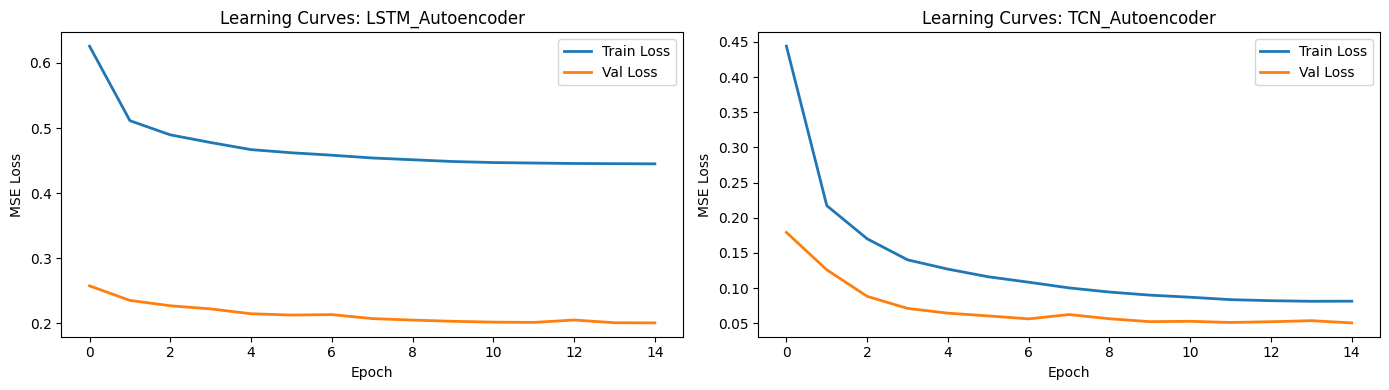


FINAL SWaT BENCHMARK EVALUATION MATRIX (Base Threshold: 98.5%)
Architecture Model   | Opt Tau  | FPR     | TPR (Recall) | Precision  | F1-Score
---------------------------------------------------------------------------
LSTM_Autoencoder     | 2.0946 | 1.47% | 71.12% | 96.81% | 82.00%
TCN_Autoencoder      | 0.2863 | 2.42% | 77.91% | 95.27% | 85.72%


In [7]:
models = {
    "LSTM_Autoencoder": DeepLSTMAutoencoder(W_SIZE, num_features, latent_dim=32),
    "TCN_Autoencoder": DeepTCNAutoencoder(W_SIZE, num_features, latent_dim=32)
}

results = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for idx, (name, model) in enumerate(models.items()):
    print(f"\n>> Executing Structure: {name}")
    trained_model, history = train_pipeline(model, train_loader, val_loader, epochs=15, lr=1e-3)
    
    val_errors, val_true, _ = compute_errors_and_metadata(trained_model, val_loader)
    test_errors, test_true, test_latents = compute_errors_and_metadata(trained_model, test_loader)

    # Base threshold setting
    optimal_tau = np.percentile(val_errors, 98.5)
    test_preds = (test_errors > optimal_tau).astype(np.float32)

    tp = np.sum((test_preds == 1) & (test_true == 1))
    fp = np.sum((test_preds == 1) & (test_true == 0))
    fn = np.sum((test_preds == 0) & (test_true == 1))
    tn = np.sum((test_preds == 0) & (test_true == 0))

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * tpr) / (precision + tpr) if (precision + tpr) > 0 else 0

    results[name] = {
        "Tau": optimal_tau, "FPR": fpr, "TPR": tpr, "F1": f1, "Precision": precision,
        "Latents": test_latents, "TrueLabels": test_true, 
        "ValErrors": val_errors, "TestErrors": test_errors
    }
    
    # Plot learning curves
    axes[idx].plot(history['train_loss'], label='Train Loss', lw=2)
    axes[idx].plot(history['val_loss'], label='Val Loss', lw=2)
    axes[idx].set_title(f"Learning Curves: {name}")
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel("MSE Loss")
    axes[idx].legend()

plt.tight_layout()
plt.show()

print("\n" + "="*75 + "\nFINAL SWaT BENCHMARK EVALUATION MATRIX (Base Threshold: 98.5%)\n" + "="*75)
print(f"{'Architecture Model':<20} | {'Opt Tau':<8} | {'FPR':<7} | {'TPR (Recall)':<12} | {'Precision':<10} | {'F1-Score':<8}")
print("-" * 75)
for name, metrics in results.items():
    print(f"{name:<20} | {metrics['Tau']:.4f} | {metrics['FPR']*100:.2f}% | {metrics['TPR']*100:.2f}% | {metrics['Precision']*100:.2f}% | {metrics['F1']*100:.2f}%")


## 8. Multi-Threshold FPR Analysis & Trade-off Curves

Carefully tuning the decision threshold on the validation set to analyze False Positive Rates at different settings.


Multi-Threshold Analysis: LSTM_Autoencoder


,Percentile,Threshold,FPR,TPR,F1,Precision
0,90.0,0.3754,0.1444,0.8093,0.7934,0.7781
1,92.0,0.4368,0.1136,0.8023,0.8088,0.8154
2,94.0,0.6175,0.0731,0.7821,0.8237,0.8700
3,95.0,0.6645,0.0559,0.7797,0.8344,0.8972
4,96.0,0.7248,0.0412,0.7783,0.8440,0.9219
5,97.0,0.7686,0.0355,0.7774,0.8477,0.9319
6,98.0,1.5291,0.0192,0.7203,0.8227,0.9590
7,98.5,2.0946,0.0147,0.7112,0.8200,0.9681
8,99.0,2.8224,0.0110,0.6977,0.8135,0.9754
9,99.5,3.1686,0.0049,0.6939,0.8155,0.9887


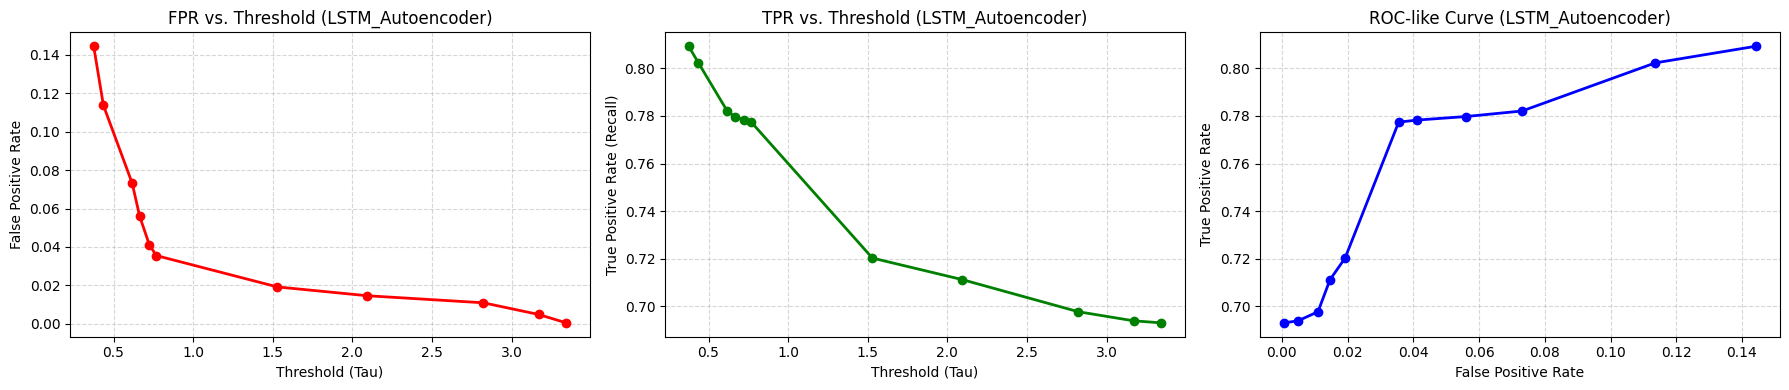


Multi-Threshold Analysis: TCN_Autoencoder


,Percentile,Threshold,FPR,TPR,F1,Precision
0,90.0,0.1042,0.2067,0.8799,0.7962,0.7270
1,92.0,0.1289,0.1239,0.8541,0.8324,0.8118
2,94.0,0.1531,0.0857,0.8348,0.8467,0.8590
3,95.0,0.1709,0.0738,0.8137,0.8425,0.8733
4,96.0,0.1961,0.0546,0.8011,0.8485,0.9017
5,97.0,0.2316,0.0365,0.7900,0.8548,0.9313
6,98.0,0.2742,0.0273,0.7812,0.8562,0.9471
7,98.5,0.2863,0.0242,0.7791,0.8572,0.9527
8,99.0,0.3124,0.0198,0.7759,0.8585,0.9608
9,99.5,0.3740,0.0088,0.7701,0.8632,0.9821


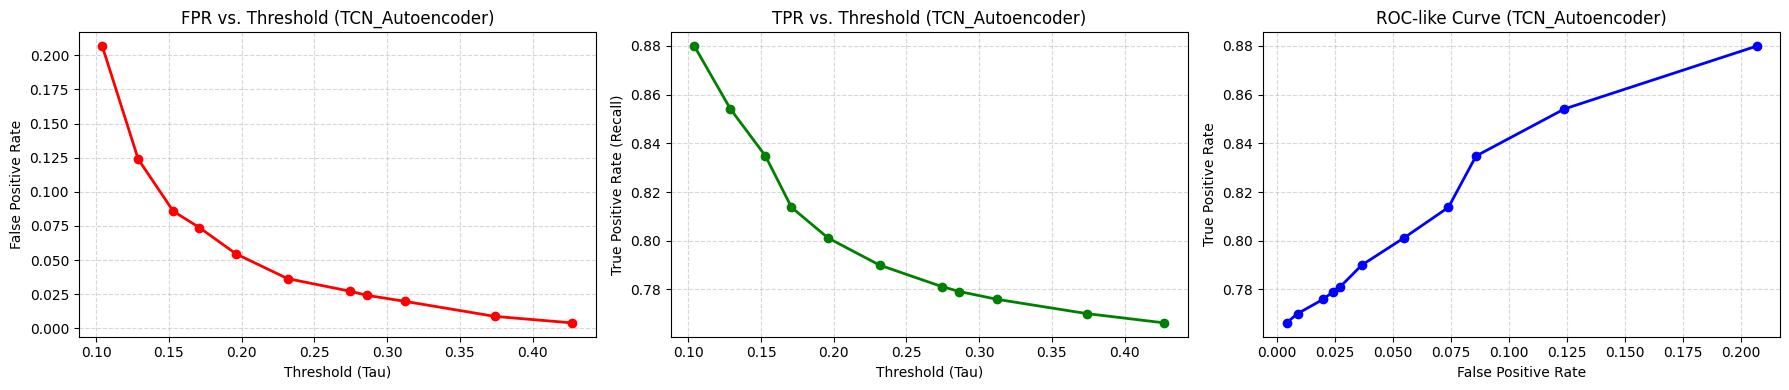

In [8]:
percentiles = [90, 92, 94, 95, 96, 97, 98, 98.5, 99, 99.5, 99.9]

for name in models.keys():
    print(f"\n{'='*50}\nMulti-Threshold Analysis: {name}\n{'='*50}")
    val_errors = results[name]['ValErrors']
    test_errors = results[name]['TestErrors']
    test_true = results[name]['TrueLabels']
    
    threshold_results = []
    
    for p in percentiles:
        tau = np.percentile(val_errors, p)
        preds = (test_errors > tau).astype(float)
        
        tp = np.sum((preds == 1) & (test_true == 1))
        fp = np.sum((preds == 1) & (test_true == 0))
        fn = np.sum((preds == 0) & (test_true == 1))
        tn = np.sum((preds == 0) & (test_true == 0))
        
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = 2 * (precision * tpr) / (precision + tpr) if (precision + tpr) > 0 else 0
        
        threshold_results.append([p, tau, fpr, tpr, f1, precision])
        
    df_thresh = pd.DataFrame(threshold_results, columns=['Percentile', 'Threshold', 'FPR', 'TPR', 'F1', 'Precision'])
    display(df_thresh.round(4))
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    
    # FPR vs Threshold
    axes[0].plot(df_thresh['Threshold'], df_thresh['FPR'], marker='o', color='red', lw=2)
    axes[0].set_title(f'FPR vs. Threshold ({name})')
    axes[0].set_xlabel('Threshold (Tau)')
    axes[0].set_ylabel('False Positive Rate')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    # TPR vs Threshold
    axes[1].plot(df_thresh['Threshold'], df_thresh['TPR'], marker='o', color='green', lw=2)
    axes[1].set_title(f'TPR vs. Threshold ({name})')
    axes[1].set_xlabel('Threshold (Tau)')
    axes[1].set_ylabel('True Positive Rate (Recall)')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    # ROC-like Curve
    axes[2].plot(df_thresh['FPR'], df_thresh['TPR'], marker='o', color='blue', lw=2)
    axes[2].set_title(f'ROC-like Curve ({name})')
    axes[2].set_xlabel('False Positive Rate')
    axes[2].set_ylabel('True Positive Rate')
    axes[2].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()


## 9. Temporal Window Size Experimentation

Testing multiple temporal window sizes to find the optimal span for capturing attack dynamics.

Running window size experiment using TCN Autoencoder...

>> Testing window size: 16
Window:  16 | F1: 0.8361 | FPR: 0.0217 | TPR: 0.7434

>> Testing window size: 32
Window:  32 | F1: 0.8607 | FPR: 0.0191 | TPR: 0.7786

>> Testing window size: 64
Window:  64 | F1: 0.8555 | FPR: 0.0172 | TPR: 0.7680

>> Testing window size: 128
Window: 128 | F1: 0.8680 | FPR: 0.0172 | TPR: 0.7879


,Window_Size,Threshold,FPR,TPR,F1
0,16,0.194715,0.021745,0.743391,0.836127
1,32,0.275753,0.019139,0.778559,0.860682
2,64,0.478866,0.017222,0.768014,0.855465
3,128,0.603198,0.017235,0.787932,0.868022


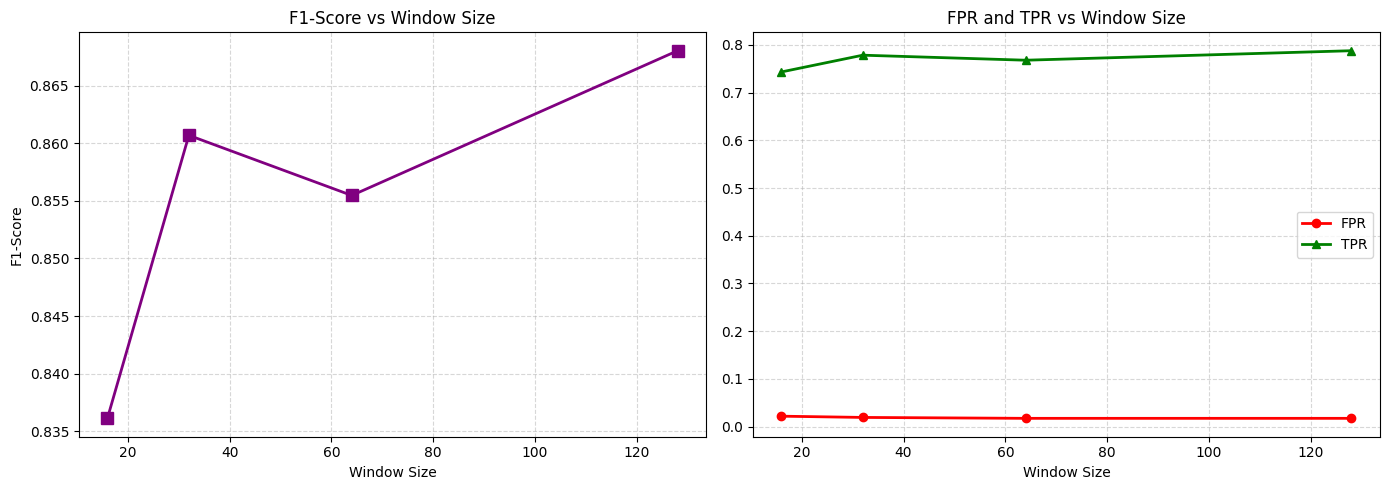

In [9]:
window_sizes = [16, 32, 64, 128]
window_results = []

print("Running window size experiment using TCN Autoencoder...")
for ws in window_sizes:
    print(f"\n>> Testing window size: {ws}")
    
    # Create new windows with stride proportional to window size
    X_train_w, Y_train_w = create_sliding_windows(scaled_train, train_labels, ws, ws//4)
    X_val_w, Y_val_w     = create_sliding_windows(scaled_val, val_labels, ws, ws//4)
    X_test_w, Y_test_w   = create_sliding_windows(scaled_test, test_labels, ws, ws//4)
    
    train_loader_w = DataLoader(TensorDataset(torch.tensor(X_train_w), torch.tensor(Y_train_w)), batch_size=256, shuffle=True)
    val_loader_w   = DataLoader(TensorDataset(torch.tensor(X_val_w), torch.tensor(Y_val_w)), batch_size=256, shuffle=False)
    test_loader_w  = DataLoader(TensorDataset(torch.tensor(X_test_w), torch.tensor(Y_test_w)), batch_size=256, shuffle=False)
    
    # Train TCN with fewer epochs for the ablation study
    model = DeepTCNAutoencoder(ws, num_features, latent_dim=32)
    trained_model, _ = train_pipeline(model, train_loader_w, val_loader_w, epochs=8, lr=1e-3, verbose=False)
    
    val_err, _, _ = compute_errors_and_metadata(trained_model, val_loader_w)
    test_err, test_tr, _ = compute_errors_and_metadata(trained_model, test_loader_w)
    
    tau = np.percentile(val_err, 98.5)
    preds = (test_err > tau).astype(float)
    
    tp = np.sum((preds == 1) & (test_tr == 1))
    fp = np.sum((preds == 1) & (test_tr == 0))
    fn = np.sum((preds == 0) & (test_tr == 1))
    tn = np.sum((preds == 0) & (test_tr == 0))
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (prec * tpr) / (prec + tpr) if (prec + tpr) > 0 else 0
    
    window_results.append([ws, tau, fpr, tpr, f1])
    print(f"Window: {ws:3d} | F1: {f1:.4f} | FPR: {fpr:.4f} | TPR: {tpr:.4f}")

df_win = pd.DataFrame(window_results, columns=['Window_Size', 'Threshold', 'FPR', 'TPR', 'F1'])
display(df_win)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(df_win['Window_Size'], df_win['F1'], marker='s', label='F1-Score', color='purple', lw=2, markersize=8)
axes[0].set_title('F1-Score vs Window Size')
axes[0].set_xlabel('Window Size')
axes[0].set_ylabel('F1-Score')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(df_win['Window_Size'], df_win['FPR'], marker='o', color='red', label='FPR', lw=2)
axes[1].plot(df_win['Window_Size'], df_win['TPR'], marker='^', color='green', label='TPR', lw=2)
axes[1].set_title('FPR and TPR vs Window Size')
axes[1].set_xlabel('Window Size')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 10. Enhanced Latent Space Visualization

Visualizing the latent representation using PCA and t-SNE to see how well normal and attack states separate, colored both by true labels and reconstruction errors.

Computing PCA and t-SNE projections on 5000 samples...


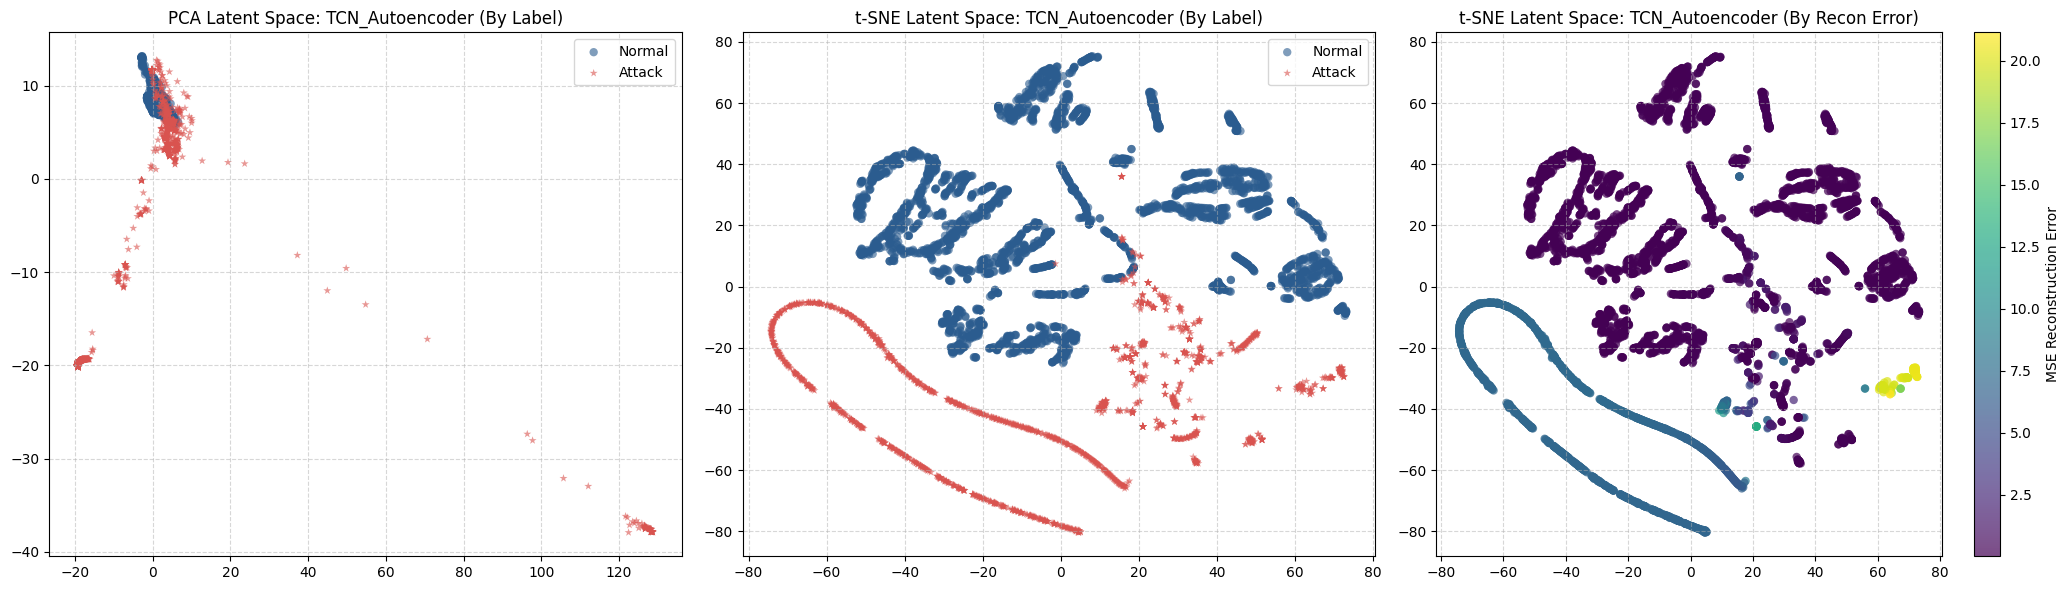

[Success] Report-ready vector graphic saved as 'enhanced_latent_space.pdf'.


In [10]:
name = "TCN_Autoencoder"
latents = results[name]['Latents']
test_true = results[name]['TrueLabels']
test_errors = results[name]['TestErrors']

# Sample subset for t-SNE performance if dataset is large
np.random.seed(42)
sample_size = min(5000, len(latents))
subset_idx = np.random.choice(len(latents), sample_size, replace=False)

latents_sub = latents[subset_idx]
labels_sub = test_true[subset_idx]
errors_sub = test_errors[subset_idx]

print(f"Computing PCA and t-SNE projections on {sample_size} samples...")
pca_proj = PCA(n_components=2).fit_transform(latents_sub)
tsne_proj = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42).fit_transform(latents_sub)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# 1. PCA Colored by Label
for label, color, marker, label_name in [(0, '#2b5c8f', 'o', 'Normal'), (1, '#d9534f', '*', 'Attack')]:
    mask = labels_sub == label
    axes[0].scatter(pca_proj[mask, 0], pca_proj[mask, 1], c=color, label=label_name, alpha=0.6, marker=marker, edgecolors='none')
axes[0].set_title(f"PCA Latent Space: {name} (By Label)")
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# 2. t-SNE Colored by Label
for label, color, marker, label_name in [(0, '#2b5c8f', 'o', 'Normal'), (1, '#d9534f', '*', 'Attack')]:
    mask = labels_sub == label
    axes[1].scatter(tsne_proj[mask, 0], tsne_proj[mask, 1], c=color, label=label_name, alpha=0.6, marker=marker, edgecolors='none')
axes[1].set_title(f"t-SNE Latent Space: {name} (By Label)")
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

# 3. t-SNE Colored by Reconstruction Error
sc = axes[2].scatter(tsne_proj[:, 0], tsne_proj[:, 1], c=errors_sub, cmap='viridis', alpha=0.7, marker='o', edgecolors='none')
axes[2].set_title(f"t-SNE Latent Space: {name} (By Recon Error)")
axes[2].grid(True, linestyle='--', alpha=0.5)
plt.colorbar(sc, ax=axes[2], label='MSE Reconstruction Error')

plt.tight_layout()
plt.savefig("enhanced_latent_space.pdf", bbox_inches="tight")
plt.show()
print("[Success] Report-ready vector graphic saved as 'enhanced_latent_space.pdf'.")


## 11. Reconstruction Error Distribution

Comparing the distribution of reconstruction errors (MSE) between Normal and Attack windows, showing the threshold decision boundary.

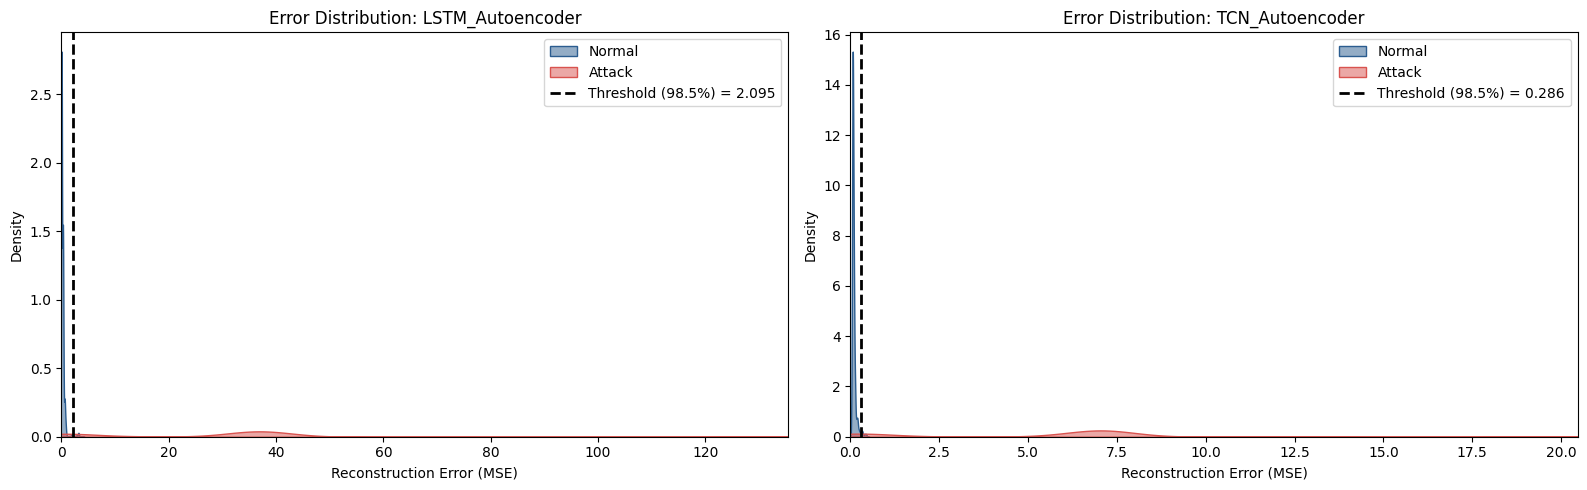

[Success] Error distributions saved as 'error_distributions.pdf'.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, name in enumerate(models.keys()):
    test_errors = results[name]['TestErrors']
    test_true = results[name]['TrueLabels']
    tau = results[name]['Tau']
    
    normal_errors = test_errors[test_true == 0]
    attack_errors = test_errors[test_true == 1]
    
    sns.kdeplot(normal_errors, fill=True, color='#2b5c8f', label='Normal', ax=axes[idx], alpha=0.5)
    sns.kdeplot(attack_errors, fill=True, color='#d9534f', label='Attack', ax=axes[idx], alpha=0.5)
    
    axes[idx].axvline(tau, color='black', linestyle='--', lw=2, label=f'Threshold (98.5%) = {tau:.3f}')
    
    axes[idx].set_title(f"Error Distribution: {name}")
    axes[idx].set_xlabel("Reconstruction Error (MSE)")
    axes[idx].set_ylabel("Density")
    
    # Limit x-axis to 99.5th percentile to handle long tails
    max_x = np.percentile(test_errors, 99.5)
    axes[idx].set_xlim(0, max_x)
    axes[idx].legend()

plt.tight_layout()
plt.savefig("error_distributions.pdf", bbox_inches="tight")
plt.show()
print("[Success] Error distributions saved as 'error_distributions.pdf'.")
